In [4]:
import yfinance as yf
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [5]:
ticker = yf.Ticker('NVDA')
df = ticker.history(start = '2020-01-01',end = '2024-12-31') 
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(1257, 7)
                               Open      High       Low     Close     Volume  \
Date                                                                           
2020-01-02 00:00:00-05:00  5.941884  5.970754  5.891363  5.970754  237536000   
2020-01-03 00:00:00-05:00  5.851046  5.918989  5.826158  5.875186  205384000   
2020-01-06 00:00:00-05:00  5.781858  5.905050  5.755726  5.899824  262636000   
2020-01-07 00:00:00-05:00  5.928196  6.017044  5.883149  5.971251  314856000   
2020-01-08 00:00:00-05:00  5.967022  6.023765  5.926953  5.982452  277108000   

                           Dividends  Stock Splits  
Date                                                
2020-01-02 00:00:00-05:00        0.0           0.0  
2020-01-03 00:00:00-05:00        0.0           0.0  
2020-01-06 00:00:00-05:00        0.0           0.0  
2020-01-07 00:00:00-05:00        0.0           0.0  
2020-01-08 00:00:00-05:00        0.0           0.0  
Open            float64
High            float64
Low       

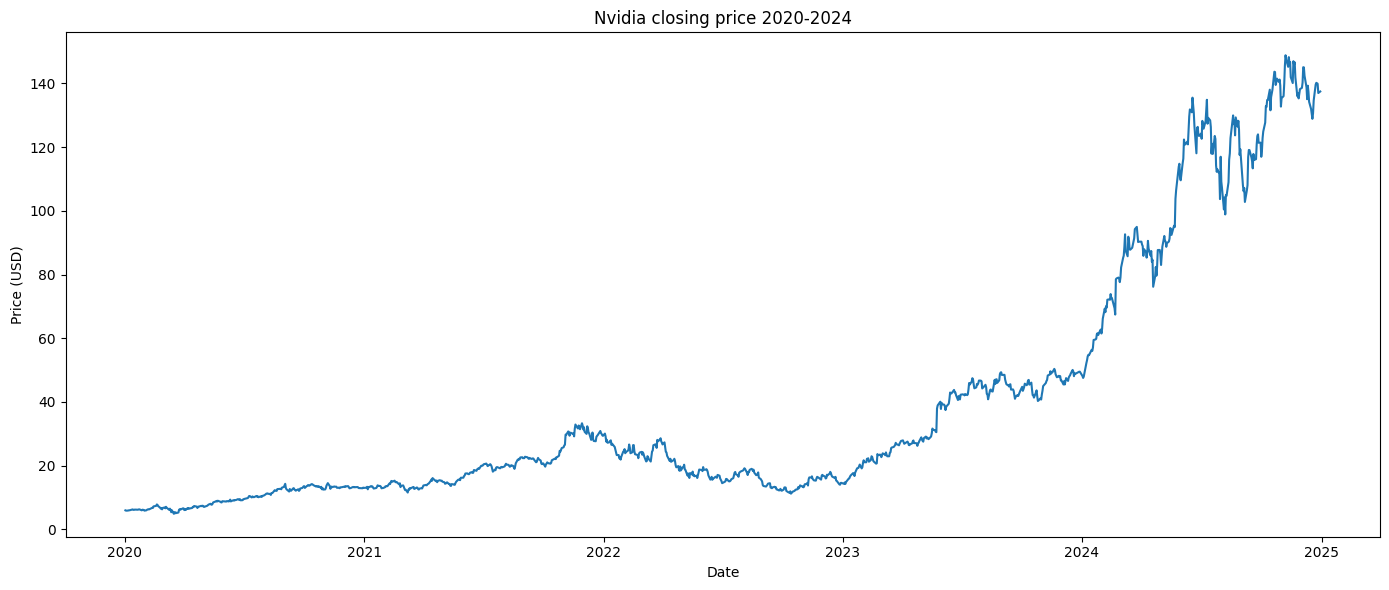

In [6]:
plt.figure(figsize = (14,6))
plt.plot(df.index,df['Close'])
plt.title('Nvidia closing price 2020-2024')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

count    1256.000000
mean        0.003071
std         0.033946
min        -0.184521
25%        -0.015979
50%         0.003297
75%         0.022333
max         0.243697
Name: Daily_Return, dtype: float64


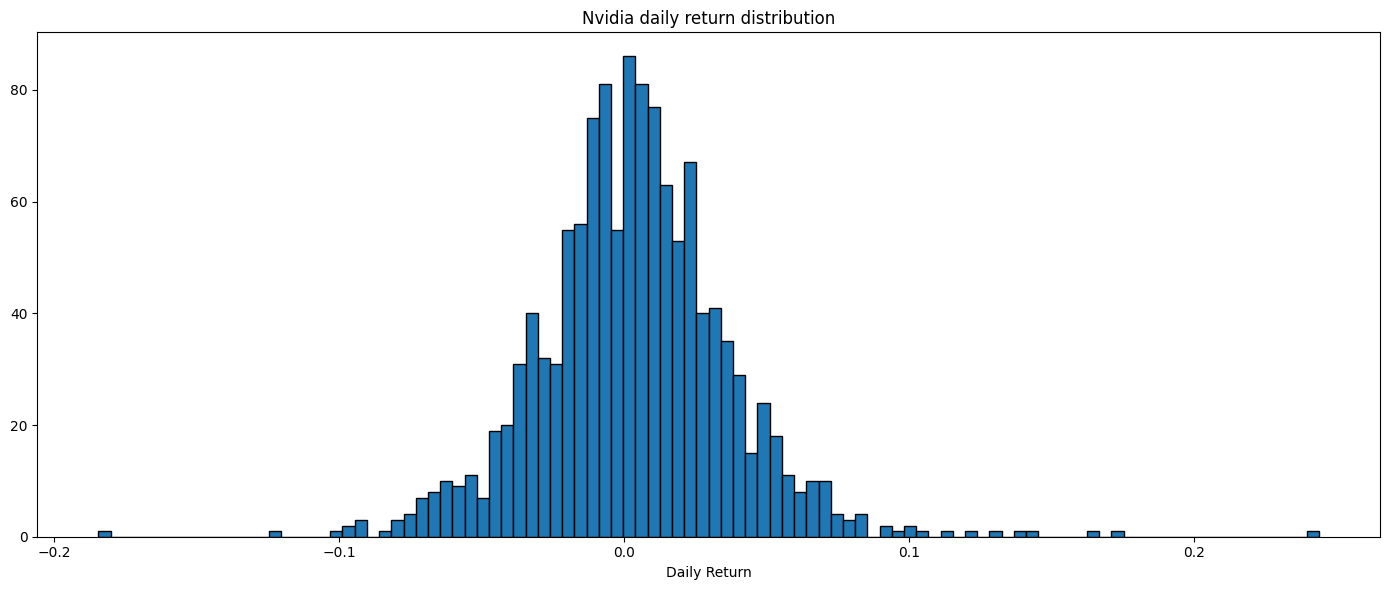

In [7]:
df['Daily_Return'] = df['Close'].pct_change()

print(df['Daily_Return'].describe())
plt.figure(figsize = (14,6))
plt.hist(df['Daily_Return'].dropna(),edgecolor = 'black',bins = 100)
plt.xlabel('Daily Return')
plt.title('Nvidia daily return distribution')
plt.tight_layout()
plt.show()

In [8]:
df['Baseline_pred'] = df['Close'].shift(1)

from sklearn.metrics import mean_absolute_percentage_error

split_idx = int(len(df) * 0.8)
test_df = df.iloc[split_idx:].dropna()

baseline_mape = mean_absolute_percentage_error(test_df['Close'],test_df['Baseline_pred']) * 100
print(f'baseline mape is {baseline_mape:.2f}%')

baseline mape is 2.46%


In [9]:
df_features = df.copy()
#lag features past closing prices 
df_features['lag_1'] = df_features['Close'].shift(1)
df_features['lag_2'] = df_features['Close'].shift(2)
df_features['lag_5'] = df_features['Close'].shift(5)
df_features['lag_10'] = df_features['Close'].shift(10)

#rolling mean average price over N days 
df_features['rolling_mean_5'] = df_features['Close'].shift(1).rolling(5).mean()
df_features['rolling_mean_20'] = df_features['Close'].shift(1).rolling(20).mean()
#rolling standard deviation - measures recent volatility 
df_features['rolling_std_5'] = df_features['Close'].shift(1).rolling(5).std()

In [10]:
#price momentum
df_features['momentum_5'] = df_features['Close'].shift(1) / df_features['Close'].shift(6) 
df_features['momentum_10'] = df_features['Close'].shift(1) / df_features['Close'].shift(11) 

#moving average crossover - when short MA croseses over long MA, bullish signal
df_features['ma_crossover'] = df_features['rolling_mean_5'] - df_features['rolling_mean_20']

In [11]:
#volume moving average
df_features['volume_ma_5'] = df_features['Volume'].shift(1).rolling(5).mean()

#volume ratio
df_features['volume_ratio']  = df_features['Volume'] / df_features['volume_ma_5']



In [12]:
df_features['Target'] = df_features['Close'].shift(-1)

df_clean = df_features.dropna()
print(f'original rows: {len(df_features)}')
print(f'clean rows: {len(df_clean)}')
print(f'columns created {df_clean.columns}')
print(df_clean.columns.to_list())

original rows: 1257
clean rows: 1236
columns created Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits',
       'Daily_Return', 'Baseline_pred', 'lag_1', 'lag_2', 'lag_5', 'lag_10',
       'rolling_mean_5', 'rolling_mean_20', 'rolling_std_5', 'momentum_5',
       'momentum_10', 'ma_crossover', 'volume_ma_5', 'volume_ratio', 'Target'],
      dtype='str')
['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Daily_Return', 'Baseline_pred', 'lag_1', 'lag_2', 'lag_5', 'lag_10', 'rolling_mean_5', 'rolling_mean_20', 'rolling_std_5', 'momentum_5', 'momentum_10', 'ma_crossover', 'volume_ma_5', 'volume_ratio', 'Target']


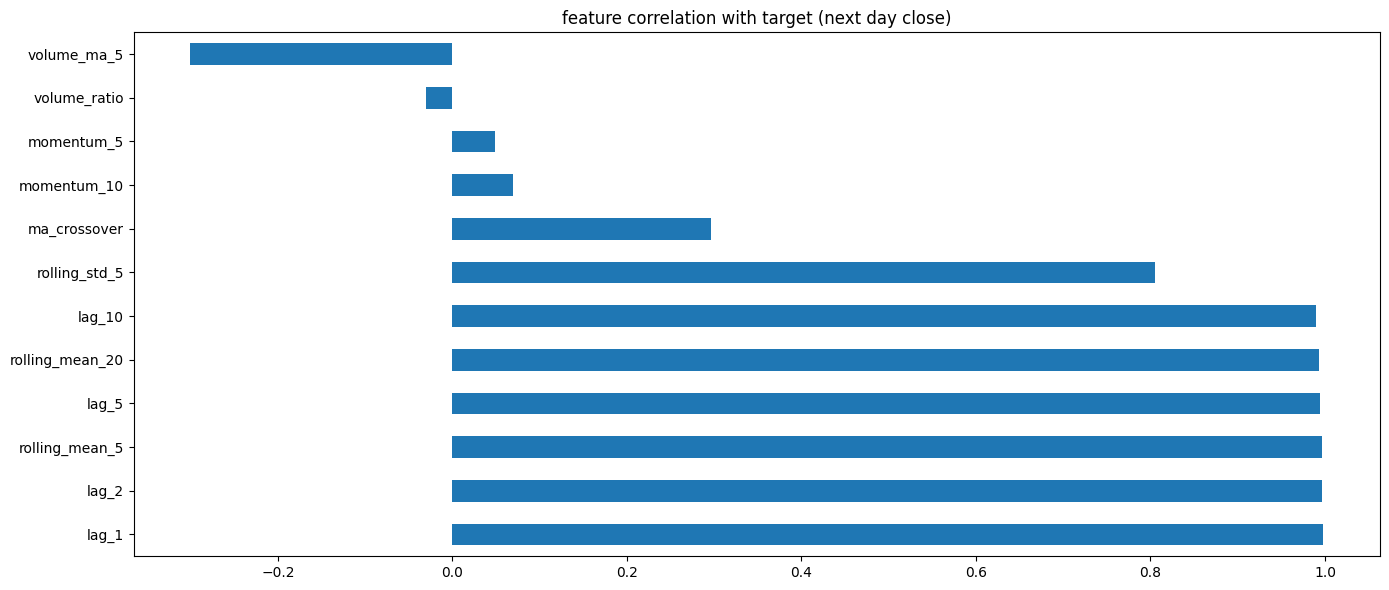

In [13]:
feature_cols = ['lag_1', 'lag_2', 'lag_5', 'lag_10', 'rolling_mean_5', 'rolling_mean_20', 'rolling_std_5', 'momentum_5', 'momentum_10', 'ma_crossover', 'volume_ma_5', 'volume_ratio']

correlations = df_clean[feature_cols + ['Target']].corr()['Target'].drop('Target').sort_values(ascending = False)

plt.figure(figsize = (14,6))
correlations.plot(kind = 'barh')
plt.title('feature correlation with target (next day close)')
plt.tight_layout()
plt.show()

In [14]:
X = df_clean[feature_cols]
Y = df_clean['Target']

print('Features shape ',X.shape)
print('Target shape ',Y.shape)
print(f'Date range is from {df_clean.index[0].date()} to {df_clean.index[-1].date()}')

Features shape  (1236, 12)
Target shape  (1236,)
Date range is from 2020-01-31 to 2024-12-27


In [15]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error

n_splits = 5
fold_size = len(X) // (n_splits + 1)

mape_scores = []
fold_results = []

In [16]:
for fold in range(n_splits):
    train_end = fold_size * (fold + 1)
    test_end = train_end + fold_size

    X_train = X.iloc[:train_end] 
    Y_train = Y.iloc[:train_end] 
    X_test = X.iloc[train_end:test_end] 
    Y_test = Y.iloc[train_end:test_end]

    model = XGBRegressor(
        n_estimators = 500,
        learning_rate = 0.1,
        early_stopping_rounds = 50,
        max_depth = 4,
        random_state = 42,
    )
    model.fit(
        X_train,Y_train,
        eval_set = [(X_test,Y_test)],
        verbose = False
    )
    preds = model.predict(X_test)
    mape = mean_absolute_percentage_error(Y_test,preds) * 100
    mape_scores.append(mape)

    fold_results.append({
        'Fold' : fold + 1,
        'Train_size' : len(X_train),
        'Test_size' : len(X_test),
        'Mape' : mape,
        'Train_start' : df_clean.index[0].date(),
        'Test_start' : df_clean.index[train_end].date()
    })
    print(f'fold {fold + 1}: train size {train_end} test start {df_clean.index[train_end].date()} mape = {mape:.2f}%')

fold 1: train size 206 test start 2020-11-23 mape = 15.90%
fold 2: train size 412 test start 2021-09-20 mape = 12.11%
fold 3: train size 618 test start 2022-07-15 mape = 4.70%
fold 4: train size 824 test start 2023-05-10 mape = 33.20%
fold 5: train size 1030 test start 2024-03-06 mape = 24.42%


In [17]:
print(f'Mean MAPE scores {np.mean(mape_scores):.2f}%')
print(f'STD MAPE {np.std(mape_scores):.2f}%')
print('baseline MAPE 2.46%')

Mean MAPE scores 18.07%
STD MAPE 9.88%
baseline MAPE 2.46%


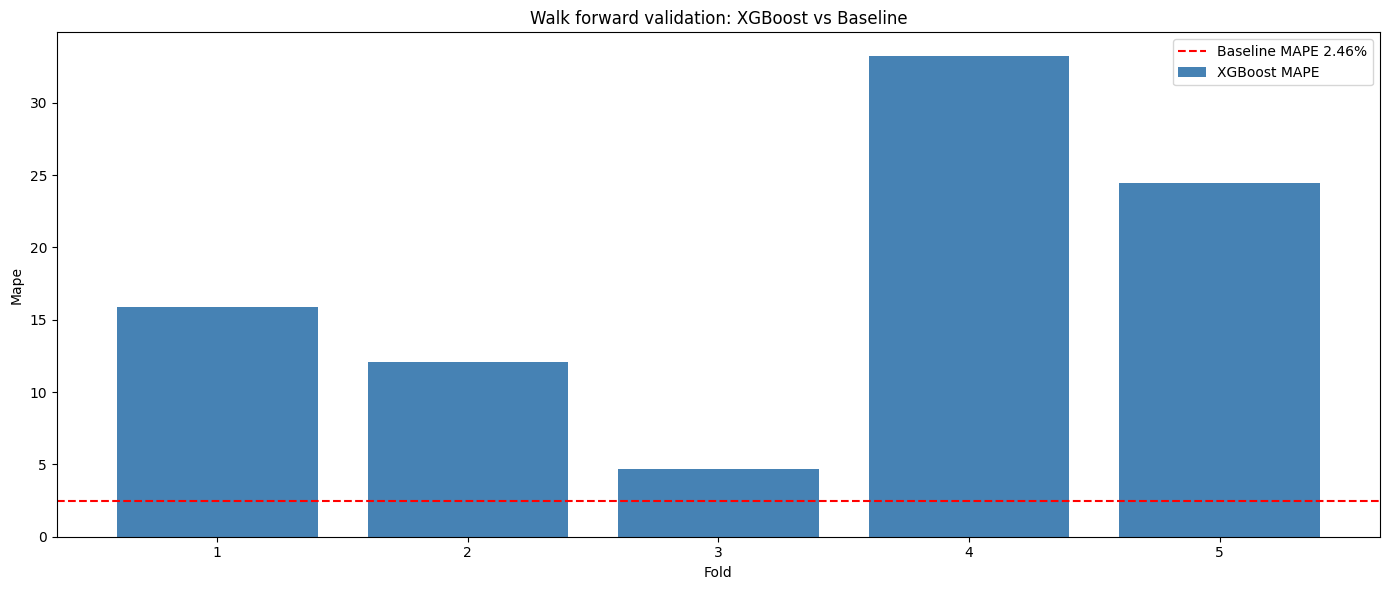

In [18]:
results_df = pd.DataFrame(fold_results)

plt.figure(figsize = (14,6))
plt.bar(results_df['Fold'],results_df['Mape'],color = 'steelblue',label = 'XGBoost MAPE')
plt.axhline(y = 2.46,color = 'red',linestyle = '--',label = 'Baseline MAPE 2.46%')
plt.xlabel('Fold')
plt.ylabel('Mape')
plt.title('Walk forward validation: XGBoost vs Baseline')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
split_idx = int(len(X) * 0.8) 

X_train_final = X.iloc[:split_idx]
Y_train_final = Y.iloc[:split_idx]
X_test_final = X.iloc[split_idx:]
Y_test_final = Y.iloc[split_idx:]

final_model = XGBRegressor(
    n_estimators = 500,
    learning_rate = 0.1,
    max_depth = 4,
    random_state = 42,
    early_stopping_rounds = 50
)
final_model.fit(
    X_train_final,
    Y_train_final,
    eval_set = [(X_test_final,Y_test_final)],
    verbose=False
)
final_preds = final_model.predict(X_test_final)
final_MAPE = mean_absolute_percentage_error(Y_test_final,final_preds) * 100

print(f'Final model MAPE {final_MAPE:.2f}%')
print('Baseline 2.46%')
print(f'improvement over baseline {((2.46 - final_MAPE) / (2.46)) * 100:.2f}')

Final model MAPE 52.24%
Baseline 2.46%
improvement over baseline -2023.64


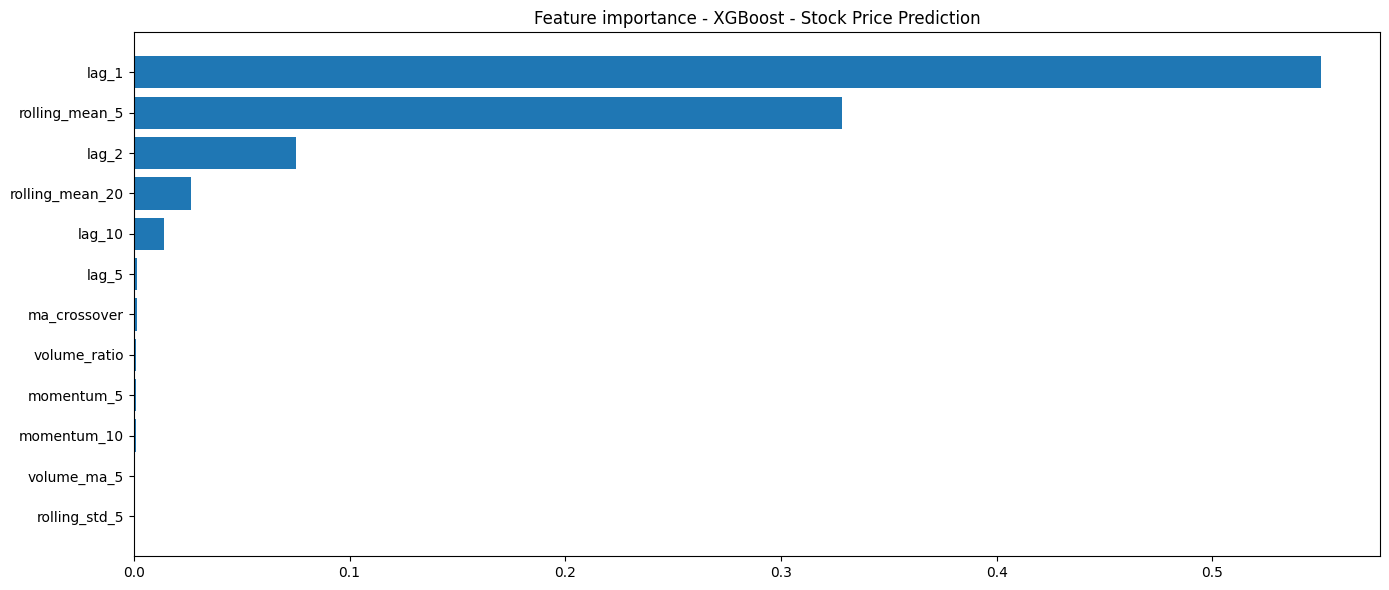

In [20]:
importance_df = pd.DataFrame({
    'feature' : feature_cols,
    'importance' : final_model.feature_importances_
}).sort_values('importance',ascending = False)

plt.figure(figsize = (14,6))
plt.barh(importance_df['feature'],importance_df['importance'])
plt.gca().invert_yaxis()
plt.title('Feature importance - XGBoost - Stock Price Prediction')
plt.tight_layout()
plt.show()

In [36]:
actual_direction = (Y_test_final.values > X_test_final['lag_1']).astype(int)

predicted_direction = (final_preds > X_test_final['lag_1']).astype(int)

direction_accuracy = (actual_direction == predicted_direction).mean() * 100

print(f'direction_accuracy {direction_accuracy:.2f}%')
print('random baseline 50%')
print(f'Improvement over baseline {direction_accuracy - 50:.2f}%')

direction_accuracy 42.34%
random baseline 50%
Improvement over baseline -7.66


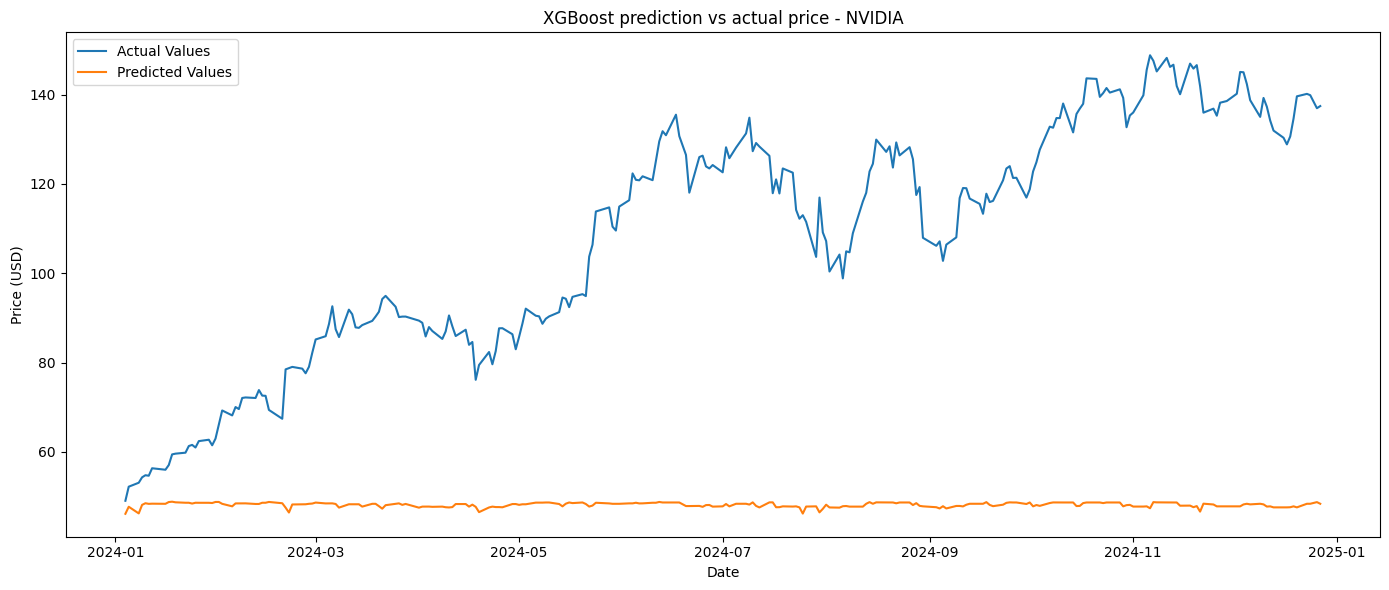

In [59]:
test_dates = df_clean.index[split_idx:]

plt.figure(figsize = (14,6))
plt.plot(test_dates,Y_test_final.values,label = 'Actual Values')
plt.plot(test_dates,final_preds,label = 'Predicted Values')
plt.title('XGBoost prediction vs actual price - NVIDIA')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
print('Honest model review')
print('Price prediciton: ')
print(f'Final MAPE {final_MAPE:.2f}%')
print('baseline mape 2.46%')
print('verdict: model worse than random walk on price')
print()
print('direction prediction')
print(f'direction accuracy {direction_accuracy:.2f}%')
print('Baseline accuracy 50.00%')
if direction_accuracy > 50:
    print('Verdict: Marginal edge on direction')
else: 
    print('Verdict: No edge on direction either ')
print()
print('walk forward results')
print(f'Mean MAPE: {np.mean(mape_scores):.2f}%')
print(f'std MAPE: {np.std(mape_scores):.2f}%')
print(f'best fold {min(mape_scores):.2f}% (stable market) ')
print(f'worst fold {max(mape_scores):.2f}% (AI boom)')

print('Conclustion')
print('Technical indicators alone cant predict NVIDIA stock')
print('Model Collapses during structural market breaks')
print('external signals (news,earnings,macro) would be required')

Honest model review
Price prediciton: 
Final MAPE 52.24%
baseline mape 2.46%
verdict: model worse than random walk on price

direction prediction
direction accuracy 42.34%
Baseline accuracy 50.00%
Verdict: No edge on direction either 

walk forward results
Mean MAPE: 18.07%
std MAPE: 9.88%
best fold 4.70% (stable market) 
worst fold 33.20% (AI boom)


In [58]:
print("What would improve this model:")
print("""
1. Sentiment features — NLP on earnings calls, news headlines
2. Macro features — interest rates, VIX (volatility index), sector ETF performance  
3. Fundamental features — P/E ratio, revenue growth, analyst estimates
4. Ensemble with regime detection — detect when market regime changes
5. Shorter prediction horizon — predict next hour instead of next day
""")

What would improve this model:

1. Sentiment features — NLP on earnings calls, news headlines
2. Macro features — interest rates, VIX (volatility index), sector ETF performance  
3. Fundamental features — P/E ratio, revenue growth, analyst estimates
4. Ensemble with regime detection — detect when market regime changes
5. Shorter prediction horizon — predict next hour instead of next day

